In [173]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd 
from sklearn.preprocessing import LabelEncoder

In [174]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path("projet").resolve().parent.parent 
data_file = BASE_DIR / "data" / "data.csv"

# Charger le fichier complet
df_full = pd.read_csv(data_file)

# Diviser en train (80%) et test (20%)
app_train, app_test = train_test_split(df_full, test_size=0.2, random_state=42, stratify=df_full['TARGET'])

print(f"Shape du dataset complet : {df_full.shape}")
print(f"Shape du train set : {app_train.shape}")
print(f"Shape du test set : {app_test.shape}")

# Optionnel : Sauvegarder les fichiers divisés
train_file = BASE_DIR / "data" / "train_split.csv"
test_file = BASE_DIR / "data" / "test_split.csv"

app_train.to_csv(train_file, index=False)
app_test.to_csv(test_file, index=False)

print(f"\n✅ Fichiers sauvegardés :")
print(f"   - {train_file}")
print(f"   - {test_file}")

Shape du dataset complet : (215257, 102)
Shape du train set : (172205, 102)
Shape du test set : (43052, 102)

✅ Fichiers sauvegardés :
   - C:\Users\hamza\Desktop\courses\PROJET CREDIT RISK\data\train_split.csv
   - C:\Users\hamza\Desktop\courses\PROJET CREDIT RISK\data\test_split.csv


In [175]:
# Vérifier que les splits sont bien chargés
print(f"Train set chargé : {app_train.shape}")
print(f"Test set chargé : {app_test.shape}")
print(f"\nDistribution de TARGET dans train : \n{app_train['TARGET'].value_counts()}")
print(f"\nDistribution de TARGET dans test : \n{app_test['TARGET'].value_counts()}")

Train set chargé : (172205, 102)
Test set chargé : (43052, 102)

Distribution de TARGET dans train : 
TARGET
0    158247
1     13958
Name: count, dtype: int64

Distribution de TARGET dans test : 
TARGET
0    39562
1     3490
Name: count, dtype: int64


In [176]:
app_train.head()

,ID,NAME_CONTRACT_TYPE,GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,EXT_SOURCE_4,TARGET
89263,220867,Revolving loans,F,Y,N,0,81000.0,180000.0,9000.0,180000.0,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0.269912,0
136259,274386,Cash loans,M,N,N,0,360000.0,1575000.0,54747.0,1575000.0,...,0,0,0.0,0.0,0.0,1.0,0.0,4.0,0.638945,0
198172,200275,Cash loans,F,N,Y,0,157500.0,808650.0,23773.5,675000.0,...,0,0,0.0,0.0,0.0,0.0,0.0,2.0,0.297963,0
101544,424902,Cash loans,F,N,Y,0,112500.0,454500.0,13419.0,454500.0,...,0,0,0.0,0.0,0.0,0.0,0.0,2.0,0.052124,1
141900,152798,Cash loans,F,N,N,2,157500.0,1024740.0,52452.0,900000.0,...,0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.068696,0


In [177]:
app_train.shape

(172205, 102)

In [178]:
app_train.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_AGE,DAYS_EMPLOYMENT,DAYS_ID_PUBLISH,OWN_CAR_AGE,...,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,EXT_SOURCE_4,TARGET
count,172205.000000,172205.000000,1.722050e+05,1.722050e+05,172197.000000,1.720530e+05,172205.000000,172205.000000,172205.000000,58741.000000,...,172205.000000,172205.000000,148924.000000,148924.000000,148924.000000,148924.000000,148924.000000,148924.000000,1.718220e+05,172205.000000
mean,277891.513626,0.415638,1.684641e+05,5.987142e+05,27117.856374,5.380214e+05,-16044.046305,64123.886223,-2995.358770,12.035563,...,0.000505,0.000314,0.006574,0.007030,0.034729,0.269983,0.266398,1.904394,2.571248e-01,0.081055
std,102714.951537,0.721294,1.041178e+05,4.017413e+05,14501.742720,3.687771e+05,4367.839284,141532.722916,1509.770369,11.886789,...,0.022471,0.017705,0.084150,0.111746,0.205129,0.930838,0.913789,1.871776,1.850121e-01,0.272920
min,100002.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,-25201.000000,-17912.000000,-6383.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.436734e-08,0.000000
25%,188905.000000,0.000000,1.125000e+05,2.700000e+05,16564.500000,2.385000e+05,-19700.000000,-2760.000000,-4299.000000,5.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.770945e-02,0.000000
50%,277581.000000,0.000000,1.485000e+05,5.147775e+05,24930.000000,4.500000e+05,-15761.000000,-1212.000000,-3258.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.257958e-01,0.000000
75%,366555.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,-12411.000000,-290.000000,-1722.000000,15.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,3.942090e-01,0.000000
max,456255.000000,19.000000,9.000000e+06,4.050000e+06,230161.500000,4.050000e+06,-7676.000000,365243.000000,0.000000,91.000000,...,1.000000,1.000000,3.000000,9.000000,8.000000,27.000000,261.000000,25.000000,8.059096e-01,1.000000


In [179]:
app_train['TARGET'].value_counts()

TARGET
0    158247
1     13958
Name: count, dtype: int64

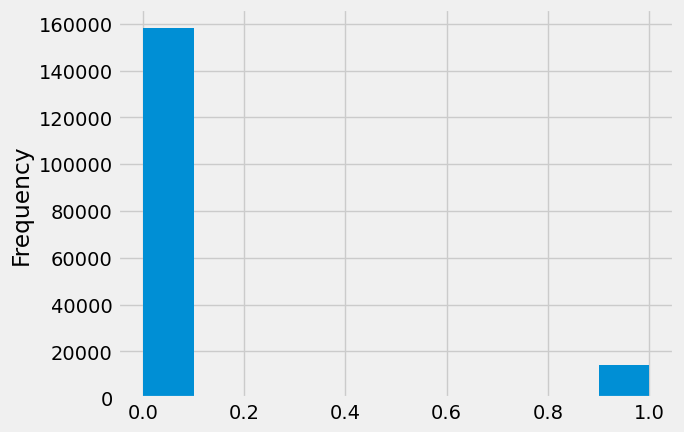

In [180]:
app_train['TARGET'].astype(int).plot.hist();

Examine Missing Values¶

In [181]:
def missing_values_table(df):
        # Total missing values
        mis_val = df.isnull().sum()
        
        # Percentage of missing values
        mis_val_percent = 100 * df.isnull().sum() / len(df)
        
        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
        
        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})
        
        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
        
        # Print some summary information
        print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"      
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")
        
        # Return the dataframe with missing information
        return mis_val_table_ren_columns

In [182]:
# Missing values statistics
missing_values = missing_values_table(app_train)
missing_values.head(20)

Your selected dataframe has 102 columns.
There are 50 columns that have missing values.


,Missing Values,% of Total Values
NONLIVINGAPARTMENTS_AVG,119480,69.4
NONLIVINGAPARTMENTS_MODE,119480,69.4
NONLIVINGAPARTMENTS_MEDI,119480,69.4
FLOORSMIN_MEDI,116664,67.7
FLOORSMIN_MODE,116664,67.7
FLOORSMIN_AVG,116664,67.7
YEARS_BUILD_AVG,114366,66.4
YEARS_BUILD_MEDI,114366,66.4
YEARS_BUILD_MODE,114366,66.4
OWN_CAR_AGE,113464,65.9


In [183]:
# Number of each type of column
app_train.dtypes.value_counts()

float64    48
int64      40
object     14
Name: count, dtype: int64

In [184]:
# Number of unique classes in each object column
app_train.select_dtypes('object').nunique()

NAME_CONTRACT_TYPE             2
GENDER                         3
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_TYPE_SUITE                7
NAME_INCOME_TYPE               8
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
OCCUPATION_TYPE               18
WEEKDAY_APPR_PROCESS_START     7
ORGANIZATION_TYPE             58
HOUSETYPE_MODE                 3
WALLSMATERIAL_MODE             7
dtype: int64

In [185]:
from sklearn.preprocessing import LabelEncoder

# Create a label encoder object
le = LabelEncoder()
le_count = 0

# Iterate through the columns
for col in app_train:
    if app_train[col].dtype == 'object':
        # If 2 or fewer unique categories
        if len(list(app_train[col].unique())) <= 2:
            # Train on the training data
            le.fit(app_train[col])
            # Transform both training and testing data
            app_train[col] = le.transform(app_train[col])
            app_test[col] = le.transform(app_test[col])
            
            # Keep track of how many columns were label encoded
            le_count += 1
            
print('%d columns were label encoded.' % le_count)

3 columns were label encoded.


In [186]:
# one-hot encoding of categorical variables
app_train = pd.get_dummies(app_train)
app_test = pd.get_dummies(app_test)

print('Training Features shape: ', app_train.shape)
print('Testing Features shape: ', app_test.shape)

Training Features shape:  (172205, 219)
Testing Features shape:  (43052, 216)


In [187]:
app_train.head()

,ID,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_AGE,...,HOUSETYPE_MODE_block of flats,HOUSETYPE_MODE_specific housing,HOUSETYPE_MODE_terraced house,WALLSMATERIAL_MODE_Block,WALLSMATERIAL_MODE_Mixed,WALLSMATERIAL_MODE_Monolithic,WALLSMATERIAL_MODE_Others,WALLSMATERIAL_MODE_Panel,"WALLSMATERIAL_MODE_Stone, brick",WALLSMATERIAL_MODE_Wooden
89263,220867,1,1,0,0,81000.0,180000.0,9000.0,180000.0,-9432,...,False,False,False,False,False,False,False,False,False,False
136259,274386,0,0,0,0,360000.0,1575000.0,54747.0,1575000.0,-13407,...,True,False,False,False,False,False,False,True,False,False
198172,200275,0,0,1,0,157500.0,808650.0,23773.5,675000.0,-19169,...,False,False,False,False,False,False,False,False,False,False
101544,424902,0,0,1,0,112500.0,454500.0,13419.0,454500.0,-20839,...,False,False,False,False,False,False,False,False,False,False
141900,152798,0,0,0,2,157500.0,1024740.0,52452.0,900000.0,-13745,...,False,False,False,False,False,False,False,False,False,False


In [188]:
# Sauvegarder les labels avant align
train_labels = app_train['TARGET']
test_labels  = app_test['TARGET']

# Align the training and testing data, keep only columns present in both dataframes
app_train, app_test = app_train.align(app_test, join='inner', axis=1)

# Add the target back in
app_train['TARGET'] = train_labels.values
app_test['TARGET']  = test_labels.values

print('Training Features shape: ', app_train.shape)
print('Testing Features shape: ', app_test.shape)

Training Features shape:  (172205, 216)
Testing Features shape:  (43052, 216)


In [189]:
(app_train['DAYS_AGE'] / -365).describe()
print('TARGET train balance:', app_train['TARGET'].value_counts(normalize=True))

TARGET train balance: TARGET
0    0.918945
1    0.081055
Name: proportion, dtype: float64


In [190]:
app_train['DAYS_EMPLOYMENT'].describe()

count    172205.000000
mean      64123.886223
std      141532.722916
min      -17912.000000
25%       -2760.000000
50%       -1212.000000
75%        -290.000000
max      365243.000000
Name: DAYS_EMPLOYMENT, dtype: float64

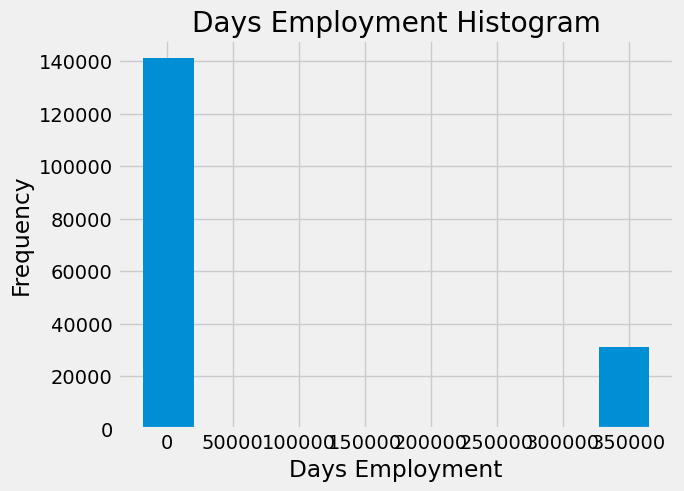

In [191]:
app_train['DAYS_EMPLOYMENT'].plot.hist(title = 'Days Employment Histogram');
plt.xlabel('Days Employment');

In [192]:
anom = app_train[app_train['DAYS_EMPLOYMENT'] == 365243]
non_anom = app_train[app_train['DAYS_EMPLOYMENT'] != 365243]
print('The non-anomalies default on %0.2f%% of loans' % (100 * non_anom['TARGET'].mean()))
print('The anomalies default on %0.2f%% of loans' % (100 * anom['TARGET'].mean()))
print('There are %d anomalous days of employment' % len(anom))

The non-anomalies default on 8.68% of loans
The anomalies default on 5.49% of loans
There are 31154 anomalous days of employment


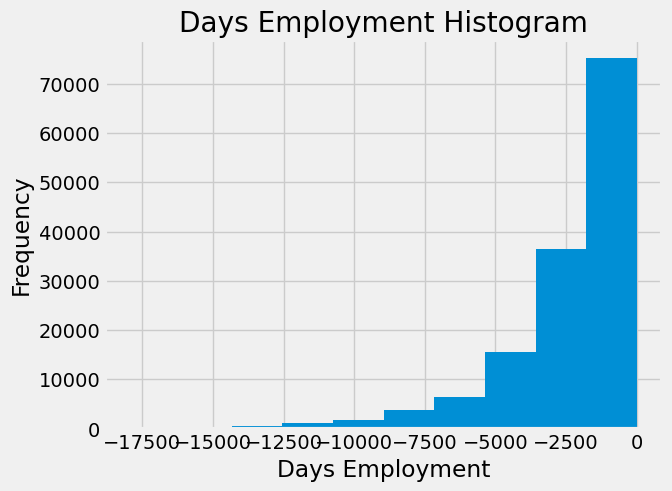

In [193]:
# Create an anomalous flag column
app_train['DAYS_EMPLOYED_ANOM'] = app_train["DAYS_EMPLOYMENT"] == 365243

# Replace the anomalous values with nan
app_train['DAYS_EMPLOYMENT'].replace({365243: np.nan}, inplace = True)

app_train['DAYS_EMPLOYMENT'].plot.hist(title = 'Days Employment Histogram');
plt.xlabel('Days Employment');


In [194]:
app_test['DAYS_EMPLOYED_ANOM'] = app_test["DAYS_EMPLOYMENT"] == 365243
app_test["DAYS_EMPLOYMENT"].replace({365243: np.nan}, inplace = True)

print('There are %d anomalies in the test data out of %d entries' % (app_test["DAYS_EMPLOYED_ANOM"].sum(), len(app_test)))

There are 7798 anomalies in the test data out of 43052 entries


C:\Users\hamza\AppData\Local\Temp\ipykernel_2332\1900126459.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  app_test["DAYS_EMPLOYMENT"].replace({365243: np.nan}, inplace = True)


In [195]:
# Find correlations with the target and sort
correlations = app_train.corr()['TARGET'].sort_values()

# Display correlations
print('Most Positive Correlations:\n', correlations.tail(15))
print('\nMost Negative Correlations:\n', correlations.head(15))

Most Positive Correlations:
 OCCUPATION_TYPE_Laborers                             0.042177
REG_CITY_NOT_LIVE_CITY                               0.045847
FLAG_DOCUMENT_3                                      0.046134
REG_CITY_NOT_WORK_CITY                               0.048348
DAYS_ID_PUBLISH                                      0.048399
NAME_EDUCATION_TYPE_Secondary / secondary special    0.050355
GENDER_M                                             0.054619
NAME_INCOME_TYPE_Working                             0.056736
REGION_RATING_CLIENT                                 0.061650
REGION_RATING_CLIENT_W_CITY                          0.062958
DAYS_EMPLOYMENT                                      0.073530
DAYS_AGE                                             0.076485
TARGET                                               1.000000
FLAG_MOBIL                                                NaN
FLAG_DOCUMENT_12                                          NaN
Name: TARGET, dtype: float64

Most Negati

In [196]:
# Find the correlation of the positive days since birth and target
app_train['DAYS_AGE'] = abs(app_train['DAYS_AGE'])
app_train['DAYS_AGE'].corr(app_train['TARGET'])

np.float64(-0.07648542182144927)

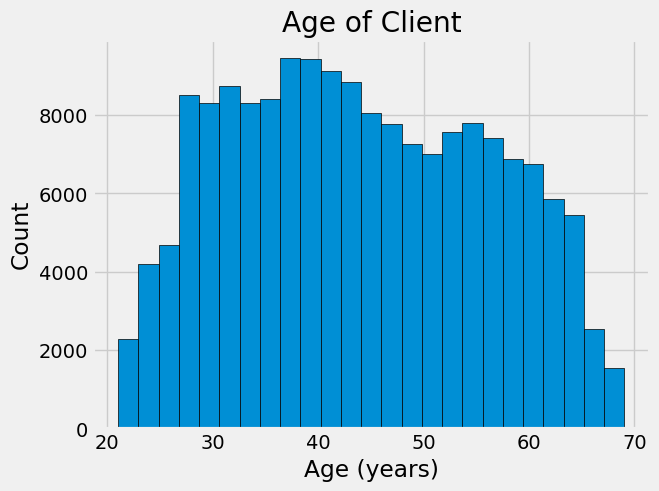

In [197]:
# Set the style of plots
plt.style.use('fivethirtyeight')

# Plot the distribution of ages in years
plt.hist(app_train['DAYS_AGE'] / 365, edgecolor = 'k', bins = 25)
plt.title('Age of Client'); plt.xlabel('Age (years)'); plt.ylabel('Count');

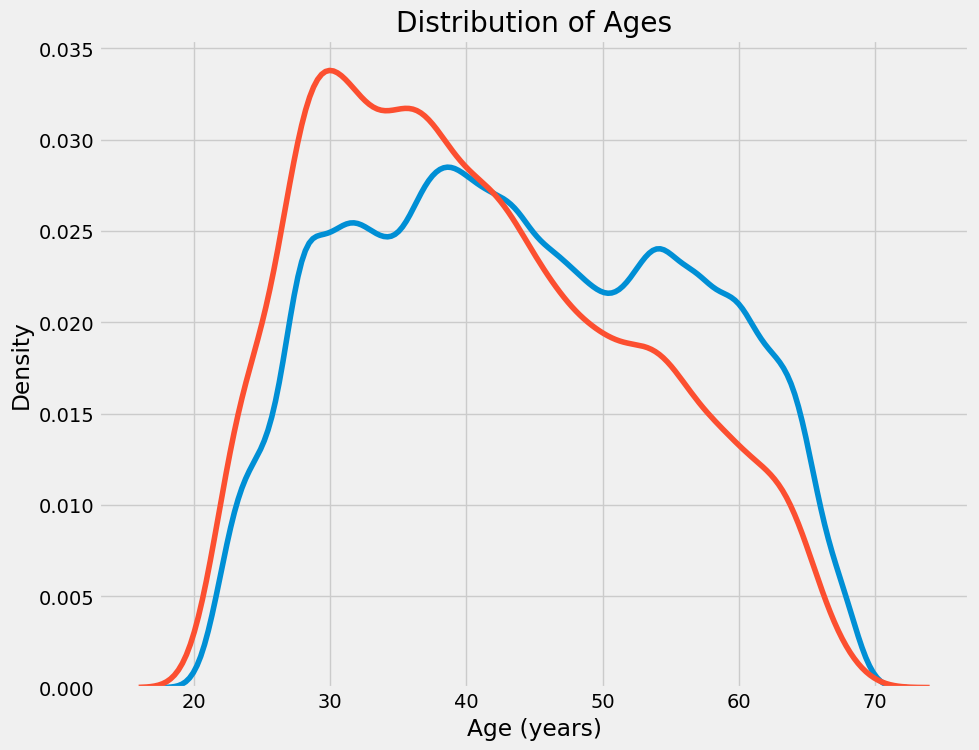

In [198]:
plt.figure(figsize = (10, 8))

# KDE plot of loans that were repaid on time
sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, 'DAYS_AGE'] / 365, label = 'target == 0')

# KDE plot of loans which were not repaid on time
sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, 'DAYS_AGE'] / 365, label = 'target == 1')

# Labeling of plot
plt.xlabel('Age (years)'); plt.ylabel('Density'); plt.title('Distribution of Ages');

In [199]:
# Extract the EXT_SOURCE variables and show correlations
ext_data = app_train[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_AGE']]
ext_data_corrs = ext_data.corr()
ext_data_corrs

,TARGET,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_AGE
TARGET,1.000000,-0.153566,-0.160073,-0.095298,-0.076485
EXT_SOURCE_1,-0.153566,1.000000,0.213483,0.100980,0.601095
EXT_SOURCE_2,-0.160073,0.213483,1.000000,0.054915,0.090700
EXT_SOURCE_3,-0.095298,0.100980,0.054915,1.000000,0.110992
DAYS_AGE,-0.076485,0.601095,0.090700,0.110992,1.000000


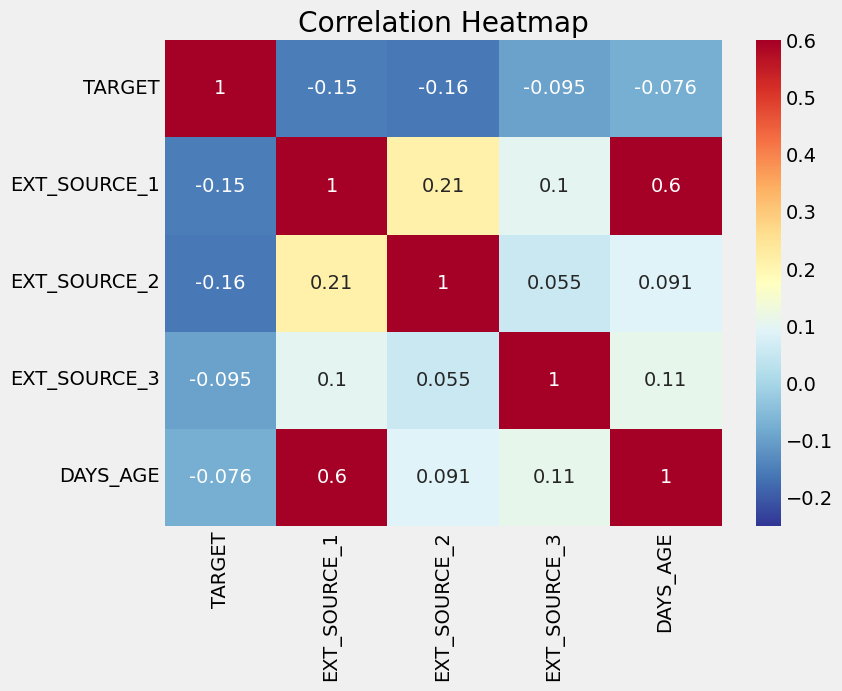

In [200]:
plt.figure(figsize = (8, 6))

# Heatmap of correlations
sns.heatmap(ext_data_corrs, cmap = plt.cm.RdYlBu_r, vmin = -0.25, annot = True, vmax = 0.6)
plt.title('Correlation Heatmap');

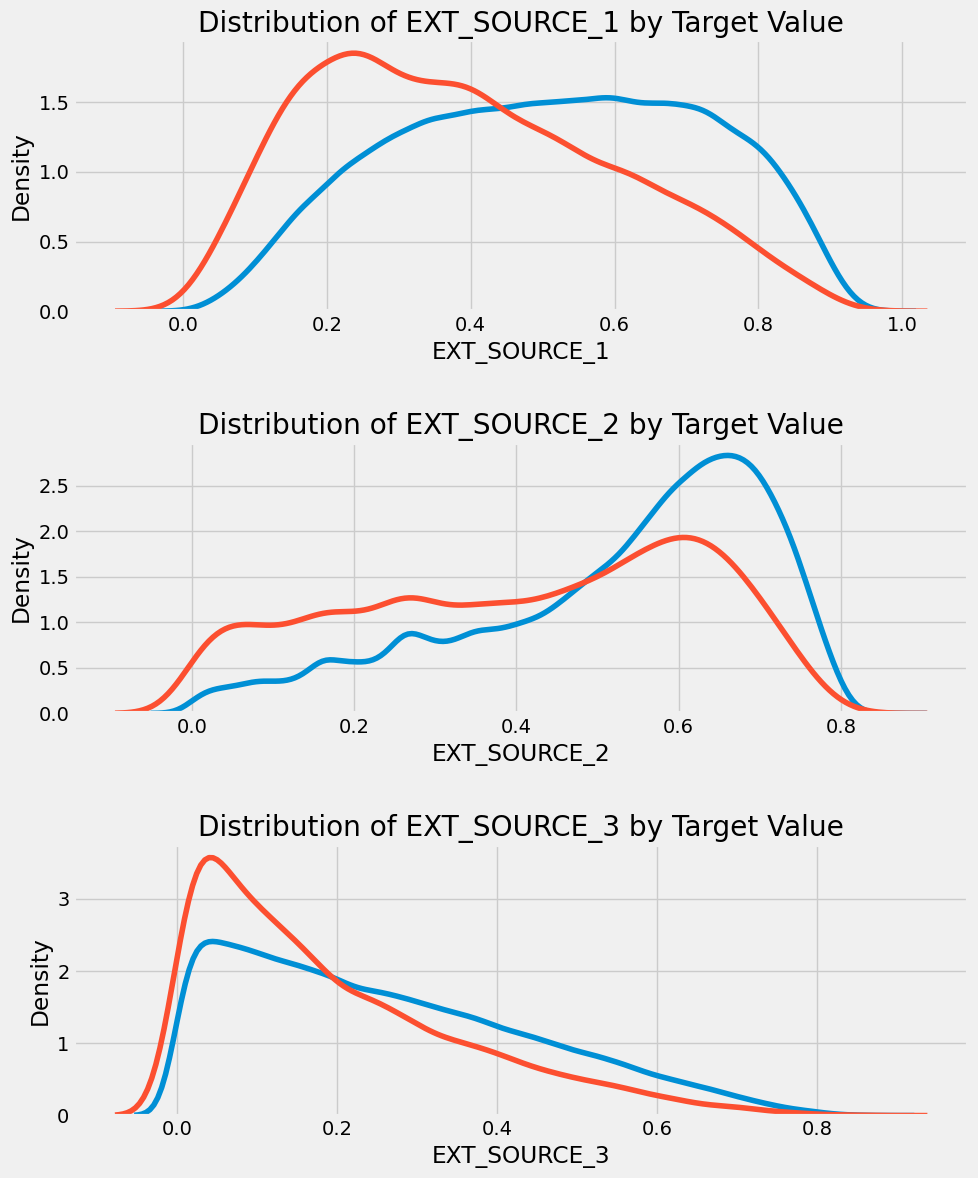

In [201]:
plt.figure(figsize = (10, 12))

# iterate through the sources
for i, source in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    
    # create a new subplot for each source
    plt.subplot(3, 1, i + 1)
    # plot repaid loans
    sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, source], label = 'target == 0')
    # plot loans that were not repaid
    sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, source], label = 'target == 1')
    
    # Label the plots
    plt.title('Distribution of %s by Target Value' % source)
    plt.xlabel('%s' % source); plt.ylabel('Density');
    
plt.tight_layout(h_pad = 2.5)

## avec les variables du domaines CREDIT

In [202]:
app_train_domain = app_train.copy()
app_test_domain = app_test.copy()

app_train_domain['CREDIT_INCOME_PERCENT'] = app_train_domain['AMT_CREDIT'] / app_train_domain['AMT_INCOME_TOTAL']
app_train_domain['ANNUITY_INCOME_PERCENT'] = app_train_domain['AMT_ANNUITY'] / app_train_domain['AMT_INCOME_TOTAL']
app_train_domain['CREDIT_TERM'] = app_train_domain['AMT_ANNUITY'] / app_train_domain['AMT_CREDIT']
app_train_domain['DAYS_EMPLOYED_PERCENT'] = app_train_domain['DAYS_EMPLOYMENT'] / app_train_domain['DAYS_AGE']

In [203]:
app_test_domain['CREDIT_INCOME_PERCENT'] = app_test_domain['AMT_CREDIT'] / app_test_domain['AMT_INCOME_TOTAL']
app_test_domain['ANNUITY_INCOME_PERCENT'] = app_test_domain['AMT_ANNUITY'] / app_test_domain['AMT_INCOME_TOTAL']
app_test_domain['CREDIT_TERM'] = app_test_domain['AMT_ANNUITY'] / app_test_domain['AMT_CREDIT']
app_test_domain['DAYS_EMPLOYED_PERCENT'] = app_test_domain['DAYS_EMPLOYMENT'] / app_test_domain['DAYS_AGE']

print('TARGET test balance:', app_test['TARGET'].value_counts(normalize=True))

TARGET test balance: TARGET
0    0.918935
1    0.081065
Name: proportion, dtype: float64


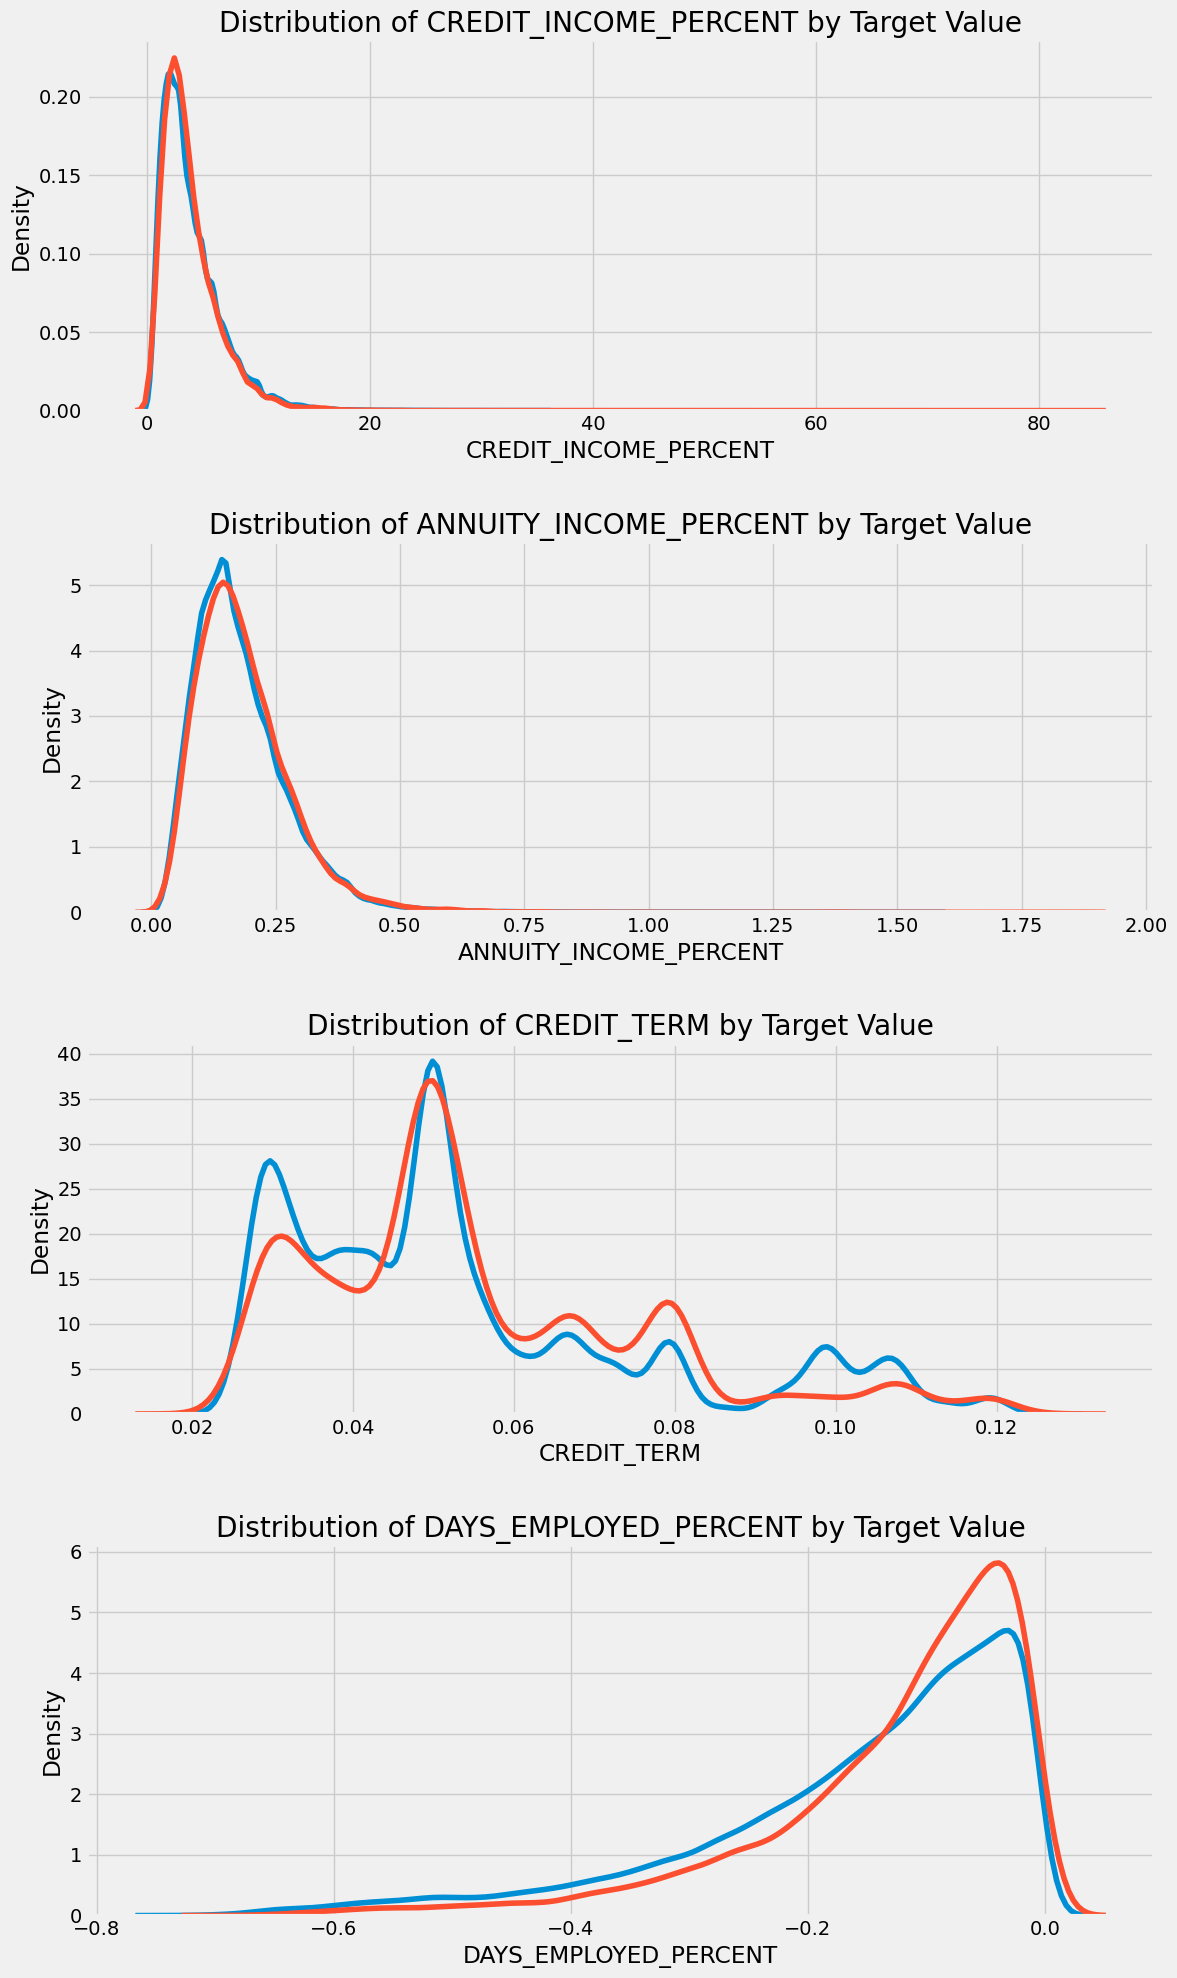

In [204]:
plt.figure(figsize = (12, 20))
# iterate through the new features
for i, feature in enumerate(['CREDIT_INCOME_PERCENT', 'ANNUITY_INCOME_PERCENT', 'CREDIT_TERM', 'DAYS_EMPLOYED_PERCENT']):
    
    # create a new subplot for each source
    plt.subplot(4, 1, i + 1)
    # plot repaid loans
    sns.kdeplot(app_train_domain.loc[app_train_domain['TARGET'] == 0, feature], label = 'target == 0')
    # plot loans that were not repaid
    sns.kdeplot(app_train_domain.loc[app_train_domain['TARGET'] == 1, feature], label = 'target == 1')
    
    # Label the plots
    plt.title('Distribution of %s by Target Value' % feature)
    plt.xlabel('%s' % feature); plt.ylabel('Density');
    
plt.tight_layout(h_pad = 2.5)

In [213]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer

# =========================
# 1. Séparer TARGET / features
# =========================

Y_train = app_train['TARGET']
X_train = app_train.drop(columns=['TARGET'])

Y_test = app_test['TARGET']
X_test = app_test.drop(columns=['TARGET'], errors='ignore')

# =========================
# 2. Imputation (median)
# =========================
imputer = SimpleImputer(strategy='median')
imputer.fit(X_train)
X_train = imputer.transform(X_train)
X_test  = imputer.transform(X_test)

# =========================
# 3. Scaling (optional for RF, kept for consistency)
# =========================
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test  = scaler.transform(X_test)

print('Training data shape:', X_train.shape)
print('Testing data shape:', X_test.shape)

Training data shape: (172205, 216)
Testing data shape: (43052, 216)


In [217]:
# Oversampling de la classe minoritaire (SMOTE)
from collections import Counter
try:
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(sampling_strategy='auto', random_state=42, k_neighbors=5)
    print('Classe avant oversampling:', Counter(Y_train))
    X_train_os, Y_train_os = smote.fit_resample(X_train, Y_train)
    print('Classe après oversampling:', Counter(Y_train_os))
    print('Shapes oversampled:', X_train_os.shape, len(Y_train_os))
except Exception as e:
    print('SMOTE indisponible. Installez imbalanced-learn (pip install imbalanced-learn).\nErreur:', e)
    # Fallback simple: utiliser les données originales
    X_train_os, Y_train_os = X_train, Y_train

Classe avant oversampling: Counter({0: 158247, 1: 13958})
Classe après oversampling: Counter({0: 158247, 1: 158247})
Shapes oversampled: (316494, 216) 316494


In [218]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest (après oversampling)
rf_clf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight=None,
    n_jobs=-1,
    random_state=42
)

# Train on the oversampled training data
rf_clf.fit(X_train_os, Y_train_os)


,n_estimators,400
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [220]:
# XGBoost Classifier (handles class imbalance via scale_pos_weight)
from xgboost import XGBClassifier
import numpy as np

# Compute scale_pos_weight = (negatives / positives) from oversampled labels if available, else original
pos = np.sum(Y_train_os) if 'Y_train_os' in globals() else np.sum(Y_train)
neg = (len(Y_train_os) - pos) if 'Y_train_os' in globals() else (len(Y_train) - pos)
spw = max(1.0, neg / max(1, pos))

xgb_clf = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective='binary:logistic',
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42,
    scale_pos_weight=spw,
    tree_method='hist'
)

# Choose training data (prefer oversampled if present)
X_tr = X_train_os if 'X_train_os' in globals() else X_train
Y_tr = Y_train_os if 'Y_train_os' in globals() else Y_train

xgb_clf.fit(X_tr, Y_tr)
print('XGBoost trained. scale_pos_weight =', spw)

XGBoost trained. scale_pos_weight = 1.0


In [219]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score, precision_recall_fscore_support, precision_recall_curve
import numpy as np

# Probabilités
y_pred_proba = rf_clf.predict_proba(X_test)[:, 1]

# --- Seuil par défaut 0.5 ---
y_pred_default = (y_pred_proba >= 0.5).astype(int)

# --- Seuil optimal sur F1 (validation interne sur test ici) ---
prec, rec, thr = precision_recall_curve(Y_test, y_pred_proba)
f1_vals = 2 * prec * rec / (prec + rec + 1e-12)
best_idx = np.nanargmax(f1_vals)
best_thr = thr[best_idx] if best_idx < len(thr) else 0.5
y_pred_best = (y_pred_proba >= best_thr).astype(int)


def report(y_true, y_pred, label):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='binary')
    precision, recall, f1_class, support = precision_recall_fscore_support(y_true, y_pred, average=None, labels=[0,1])
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n==== {label} ====")
    print('Threshold:', label)
    print('Accuracy:', acc)
    print('F1-score (binary):', f1)
    print('Precision classes [0,1]:', precision)
    print('Recall classes [0,1]:', recall)
    print('F1 classes [0,1]:', f1_class)
    print('Support classes [0,1]:', support)
    print('Confusion matrix:\n', cm)
    print('\nRapport détaillé:\n', classification_report(y_true, y_pred))

# ROC-AUC (seuil-indépendant)
roc = roc_auc_score(Y_test, y_pred_proba)
print('ROC-AUC:', roc)
print('Best F1 threshold:', best_thr)

report(Y_test, y_pred_default, 'Seuil 0.5')
report(Y_test, y_pred_best, f'Seuil F1 {best_thr:.3f}')

ROC-AUC: 0.6827986944144397
Best F1 threshold: 0.2575

==== Seuil 0.5 ====
Threshold: Seuil 0.5
Accuracy: 0.9186565084084363
F1-score (binary): 0.006242905788876277
Precision classes [0,1]: [0.91912688 0.32352941]
Recall classes [0,1]: [0.99941863 0.00315186]
F1 classes [0,1]: [0.95759264 0.00624291]
Support classes [0,1]: [39562  3490]
Confusion matrix:
 [[39539    23]
 [ 3479    11]]

Rapport détaillé:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96     39562
           1       0.32      0.00      0.01      3490

    accuracy                           0.92     43052
   macro avg       0.62      0.50      0.48     43052
weighted avg       0.87      0.92      0.88     43052


==== Seuil F1 0.258 ====
Threshold: Seuil F1 0.258
Accuracy: 0.8211697482114652
F1-score (binary): 0.23537590624689642
Precision classes [0,1]: [0.93680257 0.18011856]
Recall classes [0,1]: [0.86365704 0.33954155]
F1 classes [0,1]: [0.898744   0.23537591]
Support

In [221]:
# Evaluation for XGBoost
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score, precision_recall_fscore_support, precision_recall_curve

# Probabilités
y_pred_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]

# Seuil 0.5
y_pred_xgb = (y_pred_proba_xgb >= 0.5).astype(int)

# Seuil optimal via F1
prec_xgb, rec_xgb, thr_xgb = precision_recall_curve(Y_test, y_pred_proba_xgb)
f1_vals_xgb = 2 * prec_xgb * rec_xgb / (prec_xgb + rec_xgb + 1e-12)
best_idx_xgb = np.nanargmax(f1_vals_xgb)
best_thr_xgb = thr_xgb[best_idx_xgb] if best_idx_xgb < len(thr_xgb) else 0.5
y_pred_best_xgb = (y_pred_proba_xgb >= best_thr_xgb).astype(int)

# Metrics
def report_xgb(y_true, y_pred, label):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='binary')
    precision, recall, f1_class, support = precision_recall_fscore_support(y_true, y_pred, average=None, labels=[0,1])
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n==== XGBoost {label} ====")
    print('Accuracy:', acc)
    print('F1-score (binary):', f1)
    print('Precision classes [0,1]:', precision)
    print('Recall classes [0,1]:', recall)
    print('F1 classes [0,1]:', f1_class)
    print('Support classes [0,1]:', support)
    print('Confusion matrix:\n', cm)
    print('\nRapport détaillé:\n', classification_report(y_true, y_pred))

roc_xgb = roc_auc_score(Y_test, y_pred_proba_xgb)
print('XGBoost ROC-AUC:', roc_xgb)
print('XGBoost Best F1 threshold:', best_thr_xgb)
report_xgb(Y_test, y_pred_xgb, 'Seuil 0.5')
report_xgb(Y_test, y_pred_best_xgb, f'Seuil F1 {best_thr_xgb:.3f}')

XGBoost ROC-AUC: 0.7236647558675809
XGBoost Best F1 threshold: 0.13747469

==== XGBoost Seuil 0.5 ====
Accuracy: 0.9191675183499024
F1-score (binary): 0.010801591813530414
Precision classes [0,1]: [0.9193241  0.67857143]
Recall classes [0,1]: [0.99977251 0.00544413]
F1 classes [0,1]: [0.95786211 0.01080159]
Support classes [0,1]: [39562  3490]
Confusion matrix:
 [[39553     9]
 [ 3471    19]]

Rapport détaillé:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96     39562
           1       0.68      0.01      0.01      3490

    accuracy                           0.92     43052
   macro avg       0.80      0.50      0.48     43052
weighted avg       0.90      0.92      0.88     43052


==== XGBoost Seuil F1 0.137 ====
Accuracy: 0.8349902443556629
F1-score (binary): 0.27510204081632655
Precision classes [0,1]: [0.94170159 0.21362916]
Recall classes [0,1]: [0.87457661 0.38624642]
F1 classes [0,1]: [0.90689872 0.27510204]
Support classes [0

In [222]:
# DOMAIN FEATURES: Train/Test Split
# Assumes `app_train_domain` and `app_test_domain` exist with column `TARGET`
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report, precision_recall_curve

# Prepare domain feature matrices
assert 'TARGET' in app_train_domain.columns, "app_train_domain must include TARGET"

domain_features = [c for c in app_train_domain.columns if c != 'TARGET']
X_dom = app_train_domain[domain_features].values
y_dom = app_train_domain['TARGET']

X_dom_train, X_dom_test, y_dom_train, y_dom_test = train_test_split(
    X_dom, y_dom, test_size=0.2, random_state=42, stratify=y_dom
)

# Impute and scale (median + MinMax)
imputer_dom = SimpleImputer(strategy='median')
scaler_dom = MinMaxScaler()

X_dom_train_imputed = imputer_dom.fit_transform(X_dom_train)
X_dom_test_imputed = imputer_dom.transform(X_dom_test)

X_dom_train_scaled = scaler_dom.fit_transform(X_dom_train_imputed)
X_dom_test_scaled = scaler_dom.transform(X_dom_test_imputed)

print(f"Domain features: train={X_dom_train_scaled.shape}, test={X_dom_test_scaled.shape}")

Domain features: train=(137764, 220), test=(34441, 220)


In [223]:
# Models on DOMAIN features: RandomForest & XGBoost
from sklearn.ensemble import RandomForestClassifier
try:
    from xgboost import XGBClassifier
except Exception as e:
    XGBClassifier = None
    print("XGBoost not available:", e)

# Optional: light SMOTE to balance
try:
    from imblearn.over_sampling import SMOTE
    smote_dom = SMOTE(random_state=42)
    X_dom_train_bal, y_dom_train_bal = smote_dom.fit_resample(X_dom_train_scaled, y_dom_train)
    print("SMOTE applied (DOMAIN):", np.bincount(y_dom_train_bal))
except Exception as e:
    X_dom_train_bal, y_dom_train_bal = X_dom_train_scaled, y_dom_train
    print("SMOTE not applied (DOMAIN):", e)

# RandomForest on DOMAIN
rf_dom = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    n_jobs=-1,
    random_state=42,
)
rf_dom.fit(X_dom_train_bal, y_dom_train_bal)

# XGBoost on DOMAIN (if available)
xgb_dom = None
if XGBClassifier is not None:
    # Compute scale_pos_weight on the (balanced) training labels to avoid extreme imbalance
    pos = int((y_dom_train_bal == 1).sum())
    neg = int((y_dom_train_bal == 0).sum())
    spw_dom = max(1.0, neg / max(pos, 1))
    xgb_dom = XGBClassifier(
        objective='binary:logistic',
        tree_method='hist',
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        scale_pos_weight=spw_dom,
        random_state=42,
        n_jobs=-1,
    )
    xgb_dom.fit(X_dom_train_bal, y_dom_train_bal)
    print(f"XGB scale_pos_weight (DOMAIN): {spw_dom:.2f}")
else:
    print("Skipping XGBoost: class not available")

print("Models trained on DOMAIN features.")

SMOTE applied (DOMAIN): [126598 126598]
XGB scale_pos_weight (DOMAIN): 1.00
Models trained on DOMAIN features.


In [224]:
# Evaluation & Comparison: DOMAIN vs FULL pipeline
from sklearn.metrics import PrecisionRecallDisplay

# Helper to evaluate a classifier with PR-based F1-optimal threshold

def eval_model(name, clf, X_test_scaled, y_test):
    proba = clf.predict_proba(X_test_scaled)[:, 1]
    # default threshold
    y_def = (proba >= 0.5).astype(int)
    acc = accuracy_score(y_test, y_def)
    f1 = f1_score(y_test, y_def)
    roc = roc_auc_score(y_test, proba)
    cm_def = confusion_matrix(y_test, y_def)

    # best F1 via precision-recall curve
    prec, rec, thr = precision_recall_curve(y_test, proba)
    f1_vals = 2 * (prec * rec) / (prec + rec + 1e-9)
    best_idx = int(np.nanargmax(f1_vals))
    best_thr = thr[max(best_idx - 1, 0)] if len(thr) > 0 else 0.5
    y_best = (proba >= best_thr).astype(int)
    f1_best = f1_score(y_test, y_best)
    cm_best = confusion_matrix(y_test, y_best)

    print(f"\n[{name}] Default thr=0.50 -> acc={acc:.3f}, f1={f1:.3f}, roc_auc={roc:.3f}")
    print("Confusion (default):\n", cm_def)
    print(f"[{name}] Best thr={best_thr:.3f} -> f1={f1_best:.3f}")
    print("Confusion (best):\n", cm_best)
    return {
        'name': name,
        'acc_default': acc,
        'f1_default': f1,
        'roc_auc': roc,
        'f1_best': f1_best,
        'best_thr': float(best_thr),
    }

# Evaluate DOMAIN models
results = []
results.append(eval_model('RF_DOMAIN', rf_dom, X_dom_test_scaled, y_dom_test))
if xgb_dom is not None:
    results.append(eval_model('XGB_DOMAIN', xgb_dom, X_dom_test_scaled, y_dom_test))

# If FULL models exist in notebook, compare too
try:
    results.append(eval_model('RF_FULL', rf_clf, X_test, Y_test))
except Exception as e:
    print("RF_FULL not available:", e)
try:
    results.append(eval_model('XGB_FULL', xgb_clf, X_test, Y_test))
except Exception as e:
    print("XGB_FULL not available:", e)

# Tabular comparison
comp_df = pd.DataFrame(results)
print("\n=== MODEL COMPARISON (DOMAIN vs FULL) ===")
print(comp_df.sort_values(by=['roc_auc','f1_best'], ascending=False))


[RF_DOMAIN] Default thr=0.50 -> acc=0.917, f1=0.025, roc_auc=0.693
Confusion (default):
 [[31561    88]
 [ 2755    37]]
[RF_DOMAIN] Best thr=0.245 -> f1=0.244
Confusion (best):
 [[26643  5006]
 [ 1709  1083]]

[XGB_DOMAIN] Default thr=0.50 -> acc=0.919, f1=0.033, roc_auc=0.732
Confusion (default):
 [[31614    35]
 [ 2745    47]]
[XGB_DOMAIN] Best thr=0.172 -> f1=0.281
Confusion (best):
 [[28186  3463]
 [ 1769  1023]]

[RF_FULL] Default thr=0.50 -> acc=0.919, f1=0.006, roc_auc=0.683
Confusion (default):
 [[39539    23]
 [ 3479    11]]
[RF_FULL] Best thr=0.255 -> f1=0.235
Confusion (best):
 [[33943  5619]
 [ 2280  1210]]

[XGB_FULL] Default thr=0.50 -> acc=0.919, f1=0.011, roc_auc=0.724
Confusion (default):
 [[39553     9]
 [ 3471    19]]
[XGB_FULL] Best thr=0.137 -> f1=0.275
Confusion (best):
 [[34599  4963]
 [ 2142  1348]]

=== MODEL COMPARISON (DOMAIN vs FULL) ===
         name  acc_default  f1_default   roc_auc   f1_best  best_thr
1  XGB_DOMAIN     0.919282    0.032707  0.732044  0.